NOISE

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers,models

In [29]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test  = x_test / 255.0

# Add channel dimension
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

In [30]:
def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D(),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10)
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [31]:
model = create_model()

model.fit(x_train, y_train, epochs=20, validation_split=0.1, verbose=1)

clean_acc = model.evaluate(x_test, y_test, verbose=0)[1]

print("Clean Accuracy:", clean_acc)

c:\Users\sathv\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.0999 - loss: 2.4254 - val_accuracy: 0.0993 - val_loss: 2.3026
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.0972 - loss: 2.3024 - val_accuracy: 0.0993 - val_loss: 2.3026
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.0971 - loss: 2.3024 - val_accuracy: 0.0988 - val_loss: 2.3026
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.0969 - loss: 2.3024 - val_accuracy: 0.0985 - val_loss: 2.3026
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.1311 - loss: 2.3027 - val_accuracy: 0.1540 - val_loss: 2.3026
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1420 - loss: 2.3026 - val_accuracy: 0.1540 - val_loss: 2.3026
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1420 - loss: 2.3026 - val_accuracy: 0.1540 - val_loss: 2.3026
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.1420 - loss: 2

In [32]:
def add_gaussian_noise(images):
    noise = np.random.normal(0, 0.2, images.shape)
    noisy_images = images + noise
    noisy_images = np.clip(noisy_images, 0, 1)  # keep values valid
    return noisy_images

In [33]:
def add_salt_and_pepper_noise(images, prob=0.05):
    noisy = images.copy()
    random_vals = np.random.rand(*images.shape)

    noisy[random_vals < prob] = 0      # pepper
    noisy[random_vals > 1 - prob] = 1  # salt

    return noisy

In [34]:
x_test_gaussian = add_gaussian_noise(x_test)
x_test_sp=add_salt_and_pepper_noise(x_test)

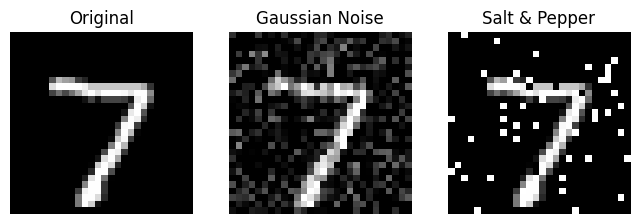

In [35]:
plt.figure(figsize=(8,3))

# Original Image
plt.subplot(1,3,1)
plt.imshow(x_test[0].squeeze(), cmap='gray')
plt.title("Original")
plt.axis('off')

# Gaussian Noise
plt.subplot(1,3,2)
plt.imshow(x_test_gaussian[0].squeeze(), cmap='gray')
plt.title("Gaussian Noise")
plt.axis('off')

# Salt & Pepper Noise
plt.subplot(1,3,3)
plt.imshow(x_test_sp[0].squeeze(), cmap='gray')
plt.title("Salt & Pepper")
plt.axis('off')

plt.show()

In [ ]:
gausian_acc= model.eva

In [36]:
# Evaluate on clean data (already done)
clean_acc = model.evaluate(x_test, y_test, verbose=0)[1]

# Evaluate on Gaussian noise
gaussian_acc = model.evaluate(x_test_gaussian, y_test, verbose=0)[1]

# Evaluate on Salt & Pepper noise
sp_acc = model.evaluate(x_test_sp, y_test, verbose=0)[1]

print("Clean Accuracy: ", clean_acc)
print("Gaussian Noise Accuracy: ", gaussian_acc)
print("Salt & Pepper Noise Accuracy: ", sp_acc)

Clean Accuracy:  0.1468999981880188
Gaussian Noise Accuracy:  0.11789999902248383
Salt & Pepper Noise Accuracy:  0.10700000077486038


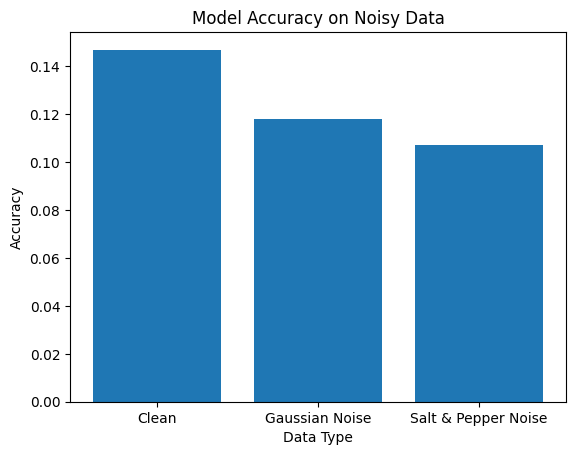

In [37]:
import matplotlib.pyplot as plt

labels = ['Clean', 'Gaussian Noise', 'Salt & Pepper Noise']
accuracies = [clean_acc, gaussian_acc, sp_acc]

plt.figure()
plt.bar(labels, accuracies)

plt.xlabel('Data Type')
plt.ylabel('Accuracy')
plt.title('Model Accuracy on Noisy Data')

plt.show()